# Solar Diameter Fit: Limb-Brightened Disk + Sunspot Floor

Fit a 5-parameter model to the raw $|V|$ data with baseline fixed from 04:

$$|V(h)| = \sqrt{A^2\left[V_{\mathrm{lb}}(q;\,R,\,\varepsilon)^2 + f^2\right] + \sigma_n^2}$$

Free parameters: $A$, $R$, $\varepsilon$, $f$, $\sigma_n$.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, NOMINAL_B_NS_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    load_processed_sun_chip_series,
    sky_baseline_lambda,
    adaptive_real_dc_correction,
    apply_chip_gain_correction, CHIP_GAIN_RATIOS_DEFAULT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE,
    SS_FINE, LW_LIGHT, LW_STANDARD, MS_FINE,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


## 1. Load data

In [2]:
# ── Load chip data ──────────────────────────────────────────────────
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
chip_data = load_processed_sun_chip_series(chip_paths)

captures    = chip_data.captures
corr_raw    = captures.corr
F_SKY_GHZ   = chip_data.f_sky_ghz
F_SKY_HZ    = F_SKY_GHZ * 1e9
unix_mid    = captures.unix_mid
ha_deg_arr  = chip_data.ha_deg
ha_rad_arr  = np.deg2rad(ha_deg_arr)
sun_dec     = chip_data.sun_dec_deg
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
dec_rad_arr  = np.deg2rad(sun_dec)
chip_slices  = chip_data.chip_slices
N_chips      = len(chip_slices)

band_mask      = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# ── DC correction ──────────────────────────────────────────────────
dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=3.0,
    min_window_caps=7,
    max_window_caps=201,
)
corr_dc = dc_result.corr_dc

# ── Chip-gain correction ──────────────────────────────────────────
import pickle as _pkl

_sidecar = Path("_chip_gain_measured.pkl")
if _sidecar.exists():
    with open(_sidecar, "rb") as _f:
        _cal = _pkl.load(_f)
    chip_gains = np.array(_cal["chip_gains_measured"])
else:
    chip_gains = np.array(CHIP_GAIN_RATIOS_DEFAULT[:N_chips])
corr_dc = apply_chip_gain_correction(corr_dc, chip_slices, chip_gains)

# ── DC-correction alpha ──────────────────────────────────────────
_dc_sidecar = Path("_dc_correction_alpha.pkl")
if _dc_sidecar.exists():
    with open(_dc_sidecar, "rb") as _f:
        DC_ALPHA = float(_pkl.load(_f)["alpha"])
    if abs(DC_ALPHA - 1.0) > 1e-6:
        corr_dc = corr_dc / DC_ALPHA

# ── Load adopted baseline ────────────────────────────────────────
import pickle
with open("_baseline_adopted.pkl", "rb") as f:
    _bl = pickle.load(f)
B_EW = _bl["b_ew_m"]
B_EW_ERR = _bl["b_ew_err_m"]
B_NS = _bl["b_ns_m"]
B_NS_ERR = _bl["b_ns_err_m"]

good_ch = band_mask & ~np.isin(np.arange(corr_dc.shape[1]), list(BAD_CHANNELS))
band_indices = np.where(good_ch)[0]
all_ch = band_indices

print(f"Captures: {len(unix_mid)}, Good channels: {good_ch.sum()}")
print(f"Baseline: B_EW = {B_EW:.4f} +/- {B_EW_ERR:.4f} m, B_NS = {B_NS:.4f} +/- {B_NS_ERR:.4f} m")
print(f"Dec: {np.rad2deg(dec_rad_mean):.3f} deg")

Captures: 8226, Good channels: 285
Baseline: B_EW = 15.1148 +/- 0.0000 m, B_NS = 1.4746 +/- 0.0000 m
Dec: -0.083 deg


## 2. Model definition

**Limb-brightened disk:** $I(\rho) = I_0[1 + \varepsilon(\rho/R)^2]$.

**Sunspot** (unresolved, unknown phase): adds in quadrature.

$$|V(h)| = \sqrt{A^2\left[V_{\mathrm{lb}}^2 + f^2\right] + \sigma_n^2}$$

Baseline $(B_{\mathrm{ew}}, B_{\mathrm{ns}})$ fixed from 04.

**5 free parameters:** $A$, $R$, $\varepsilon$, $f$, $\sigma_n$.

In [3]:
from scipy.special import j0 as J0, j1 as J1
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

# Precompute limb-brightening Hankel integral on a lookup table
_X_LUT = np.linspace(0, 60, 5000)
_V_QUAD_LUT = np.empty_like(_X_LUT)
for _i, _xi in enumerate(_X_LUT):
    if _xi < 1e-8:
        _V_QUAD_LUT[_i] = 0.5
    else:
        _integrand = lambda t, xi=_xi: t**3 * J0(xi * t)
        _V_QUAD_LUT[_i] = 2.0 * quad(_integrand, 0, 1)[0]
_v_quad_interp = interp1d(_X_LUT, _V_QUAD_LUT, kind='cubic',
                           bounds_error=False, fill_value=0.0)
print(f"LUT precomputed: {len(_X_LUT)} points, x in [0, {_X_LUT[-1]}]")


def limb_brightened_visibility(q_lambda, R_rad, epsilon):
    x = 2.0 * np.pi * np.abs(q_lambda) * R_rad
    v_disk = np.where(x > 1e-8, 2.0 * J1(x) / x, 1.0)
    v_quad = _v_quad_interp(x)
    return (v_disk + epsilon * v_quad) / (1.0 + epsilon / 2.0)


_SIN_LAT = np.sin(np.deg2rad(NCH_LAT_DEG))
_COS_LAT = np.cos(np.deg2rad(NCH_LAT_DEG))


def compute_q(ha_rad, dec_rad, b_ew, b_ns, freq_hz):
    lam = C_LIGHT_MS / freq_hz
    cos_dec = np.cos(dec_rad)
    u = (b_ew / lam) * cos_dec * np.cos(ha_rad) - (b_ns / lam) * _SIN_LAT * cos_dec * np.sin(ha_rad)
    v0 = (b_ns / lam) * _COS_LAT
    return np.sqrt(u**2 + v0**2)


def model_V_abs_full(ha_rad, A, R, eps, f, sigma_n, b_ew, b_ns,
                     dec_rad=None, freq_hz=None):
    q = compute_q(ha_rad, dec_rad, b_ew, b_ns, freq_hz)
    v_lb = limb_brightened_visibility(q, R, eps)
    return np.sqrt(A**2 * (v_lb**2 + f**2) + sigma_n**2)


# Sanity check
q_test = compute_q(np.linspace(-np.pi/2, 0, 100), dec_rad_mean, B_EW, B_NS, band_center_hz)
print(f"q range: [{q_test.min():.0f}, {q_test.max():.0f}] wavelengths")
print("Model defined.")

LUT precomputed: 5000 points, x in [0, 60.0]
q range: [51, 529] wavelengths
Model defined.


## 3. Load priors and fit per channel

$R$ bounded $\pm$5% of 05b prior. Baseline fixed from 04.

In [4]:
# Load per-channel R from 05b
import pickle as _pkl

_r_prior_path = Path("_R_prior_per_ch.pkl")
if _r_prior_path.exists():
    with open(_r_prior_path, "rb") as _f:
        _r_data = _pkl.load(_f)
    R_prior_per_ch = _r_data["R_prior_per_ch"]
    D_ivw_05b = _r_data["D_ivw"]
    D_ivw_err_05b = _r_data["D_ivw_err"]
    R_prior_ivw = _r_data["R_prior_ivw"]
    print(f"Loaded R_prior for {len(R_prior_per_ch)} channels from 05b")
    print(f"IVW diameter from 05b: {D_ivw_05b:.3f} +/- {D_ivw_err_05b:.3f} arcmin")
else:
    raise FileNotFoundError(f"{_r_prior_path} not found — run notebook 05b first")

# Single representative channel
k_mid = all_ch[len(all_ch) // 2]
print(f"Representative channel: ch {k_mid} ({F_SKY_GHZ[k_mid]:.3f} GHz)")


Loaded R_prior for 285 channels from 05b
IVW diameter from 05b: 34.317 +/- 0.022 arcmin
Representative channel: ch 655 (10.450 GHz)


In [5]:
def fit_channel(k_ch):
    if k_ch in R_prior_per_ch:
        R0 = R_prior_per_ch[k_ch]["R_mean"]
    else:
        R0 = R_prior_ivw

    freq_hz = float(F_SKY_HZ[k_ch])
    env = np.abs(corr_dc[:, k_ch])
    finite = np.isfinite(env) & np.isfinite(ha_rad_arr)
    ha_fit = ha_rad_arr[finite]
    env_fit = env[finite]
    A0 = float(np.nanmax(env_fit))

    q_fit = compute_q(ha_fit, dec_rad_mean, B_EW, B_NS, freq_hz)

    def _model(q_arr, A, R, eps, f, sigma):
        v_lb = limb_brightened_visibility(q_arr, R, eps)
        return np.sqrt(A**2 * (v_lb**2 + f**2) + sigma**2)

    try:
        popt, pcov = curve_fit(
            _model, q_fit, env_fit,
            p0=[A0, R0, 0.1, 0.02, A0 * 0.01],
            bounds=(
                [0,      R0*0.95, 0,   0,    0],
                [A0*3,   R0*1.05, 2.0, 0.15, A0*0.2],
            ),
            maxfev=20000,
        )
        perr = np.sqrt(np.diag(pcov))
        names = ["A", "R", "eps", "f", "sigma_n"]
        result = {n: float(popt[i]) for i, n in enumerate(names)}
        result.update({n + "_err": float(perr[i]) for i, n in enumerate(names)})
        result["R_prior"] = R0
        return result
    except (RuntimeError, ValueError):
        return None


res = fit_channel(k_mid)
if res is not None:
    D = np.rad2deg(2 * res["R"]) * 60
    D_err = np.rad2deg(2 * res["R_err"]) * 60
    print(f"ch {k_mid} ({F_SKY_GHZ[k_mid]:.3f} GHz):")
    print(f"  A = {res['A']:.4f} +/- {res['A_err']:.4f}")
    print(f"  D = {D:.2f} +/- {D_err:.2f}'")
    print(f"  eps = {res['eps']:.3f} +/- {res['eps_err']:.3f}")
    print(f"  f = {res['f']:.4f} +/- {res['f_err']:.4f}")
    print(f"  sigma_n = {res['sigma_n']:.4f} +/- {res['sigma_n_err']:.4f}")
else:
    print(f"ch {k_mid}: fit failed")

ch 655 (10.450 GHz):
  A = 2.5586 +/- 0.0561
  D = 33.38 +/- 0.04'
  eps = 2.000 +/- 0.220
  f = 0.0271 +/- 7183.4930
  sigma_n = 0.0214 +/- 59544.0693


## 4. Visualisation: fit vs data (representative channel)

/tmp/ipykernel_820543/3616528594.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


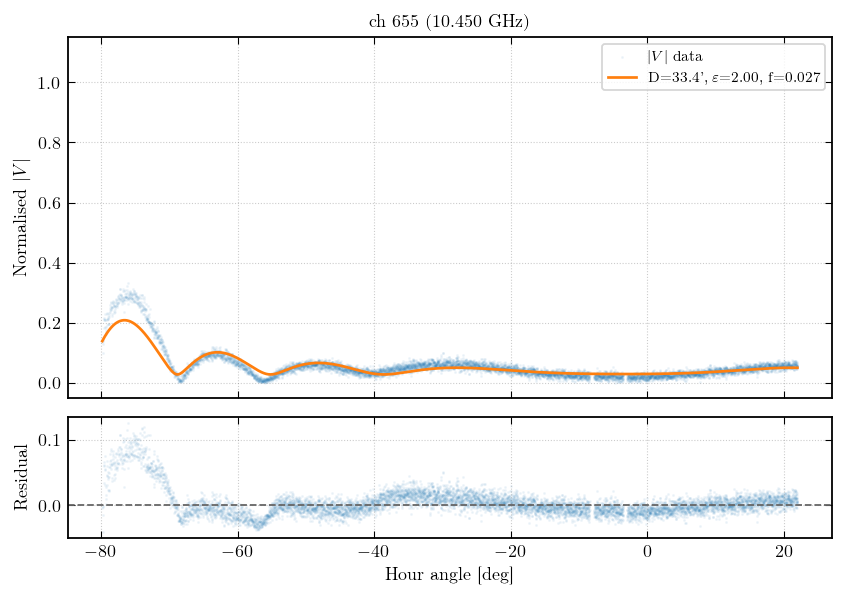

In [6]:
fr = res

freq_hz = float(F_SKY_HZ[k_mid])
env_raw = np.abs(corr_dc[:, k_mid])
finite = np.isfinite(env_raw) & np.isfinite(ha_deg_arr)

ha_fine_deg = np.linspace(ha_deg_arr[finite].min(), ha_deg_arr[finite].max(), 2000)
ha_fine_rad = np.deg2rad(ha_fine_deg)
q_fine = compute_q(ha_fine_rad, dec_rad_mean, B_EW, B_NS, freq_hz)
v_lb_fine = limb_brightened_visibility(q_fine, fr["R"], fr["eps"])
fit_curve = np.sqrt(fr["A"]**2 * (v_lb_fine**2 + fr["f"]**2) + fr["sigma_n"]**2)

V0 = fr["A"]
D_show = np.rad2deg(2 * fr["R"]) * 60

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 5.0),
                                      gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
                                      sharex=True)

ax_top.scatter(ha_deg_arr[finite], env_raw[finite] / V0,
               s=0.3, alpha=0.08, color="C0", rasterized=True, label="$|V|$ data")

fit_label = (f"D={D_show:.1f}', "
             rf"$\varepsilon$={fr['eps']:.2f}, "
             f"f={fr['f']:.3f}")
ax_top.plot(ha_fine_deg, fit_curve / V0, lw=LW_STANDARD, color="C1", label=fit_label)

ax_top.set_ylabel("Normalised $|V|$")
ax_top.set_title(f"ch {k_mid} ({F_SKY_GHZ[k_mid]:.3f} GHz)", fontsize=TICK_SIZE)
ax_top.legend(fontsize=TICK_SIZE - 2, loc="upper right")
ax_top.set_ylim(-0.05, 1.15)
ax_top.tick_params(labelbottom=False)

q_raw = compute_q(ha_rad_arr[finite], dec_rad_mean, B_EW, B_NS, freq_hz)
v_lb_raw = limb_brightened_visibility(q_raw, fr["R"], fr["eps"])
resid_model = np.sqrt(fr["A"]**2 * (v_lb_raw**2 + fr["f"]**2) + fr["sigma_n"]**2)
resid = env_raw[finite] / V0 - resid_model / V0
ax_bot.scatter(ha_deg_arr[finite], resid,
               s=0.3, alpha=0.08, color="C0", rasterized=True)
ax_bot.axhline(0, color="0.4", lw=LW_LIGHT, ls="--")
ax_bot.set_xlabel("Hour angle [deg]")
ax_bot.set_ylabel("Residual")

fig.tight_layout()
plt.show()